# (02) gaussian-relu, vH16: (16, 16.0)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Trainer

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['latent_act'] = 'relu'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 16.0

cfg_tr['epochs'] = 600

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

gaussian_relu_vH16_t-16_z-[512]_u-(7,2),du-(7,3)_<grad|lin>
b200-ep600-lr(0.005)_beta(16:0.1)_gr(500)_(2025_03_04,10:04)

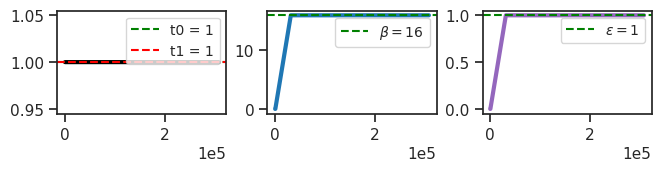

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

GaussianReluLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [6]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 600, avg loss: 278.031: 100%|███████| 600/600 [6:49:50<00:00, 40.98s/it]


epoch # 300, avg loss: 277.816: 100%|███████| 300/300 [3:46:06<00:00, 45.22s/it]


In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.2452], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0416], device='cuda:1', grad_fn=<ExpBackward0>))

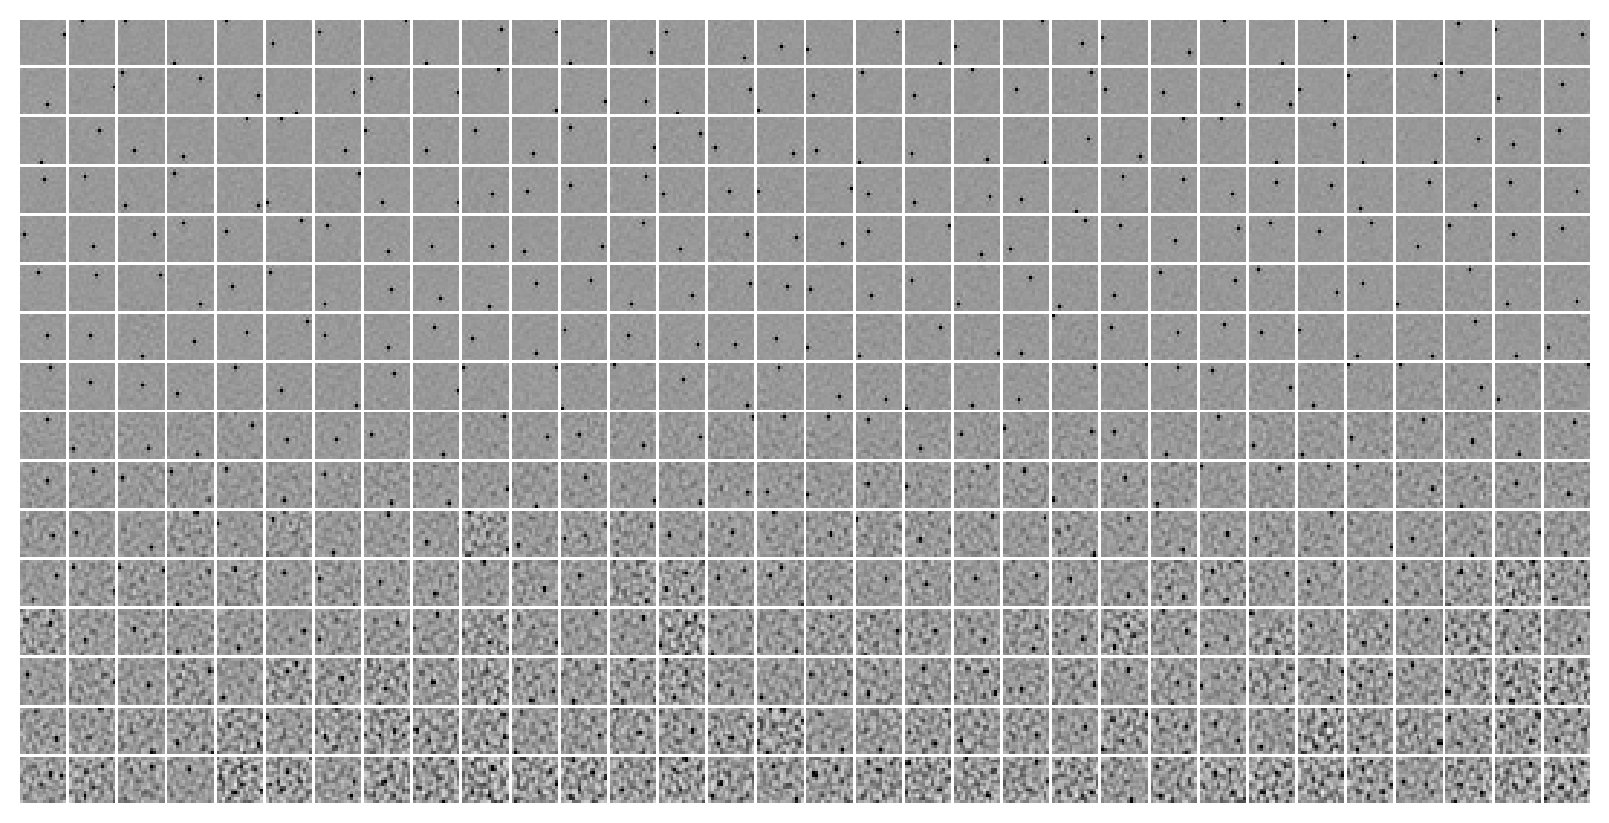

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), method='abs-max');

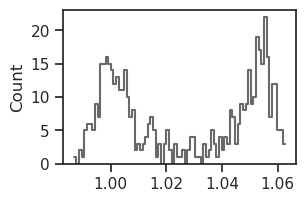

In [10]:
histplot(u0, bins=80, color='dimgrey');

In [11]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

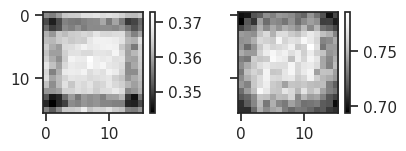

In [12]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:48<00:00, 24.46s/it]


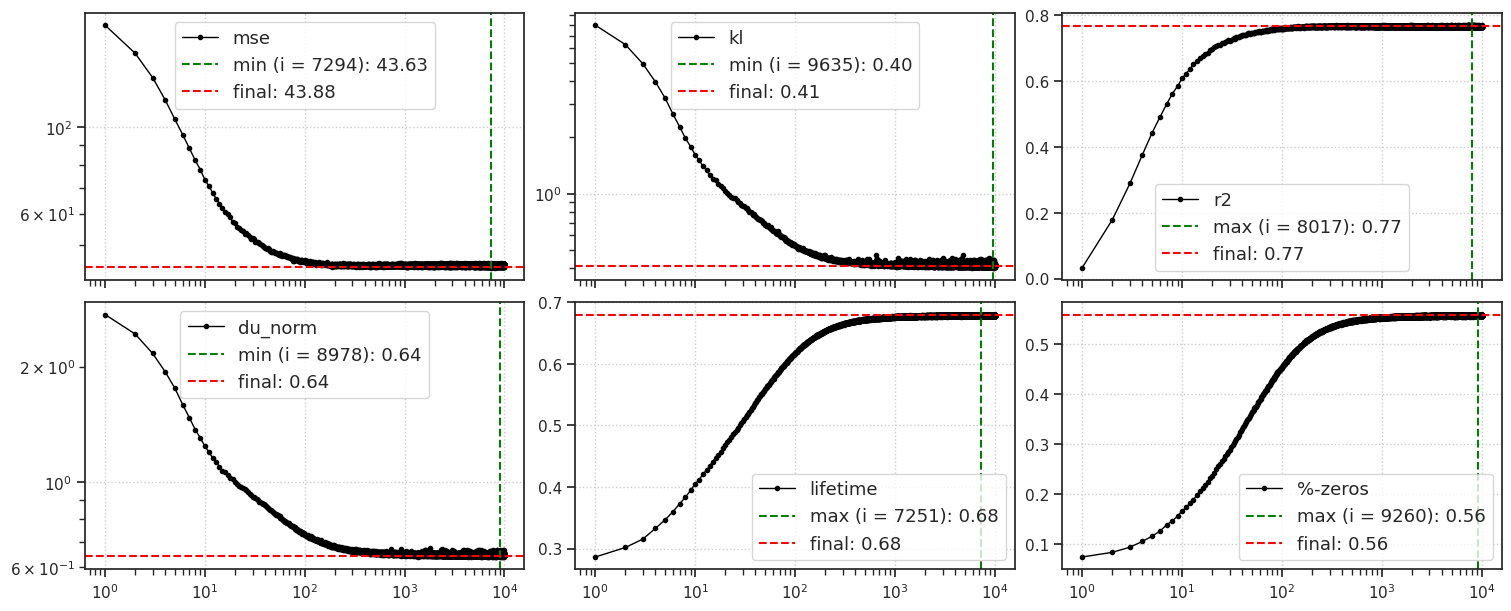

CPU times: user 1min 4s, sys: 25 s, total: 1min 29s
Wall time: 1min 29s


In [13]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:55<00:00, 27.80s/it]


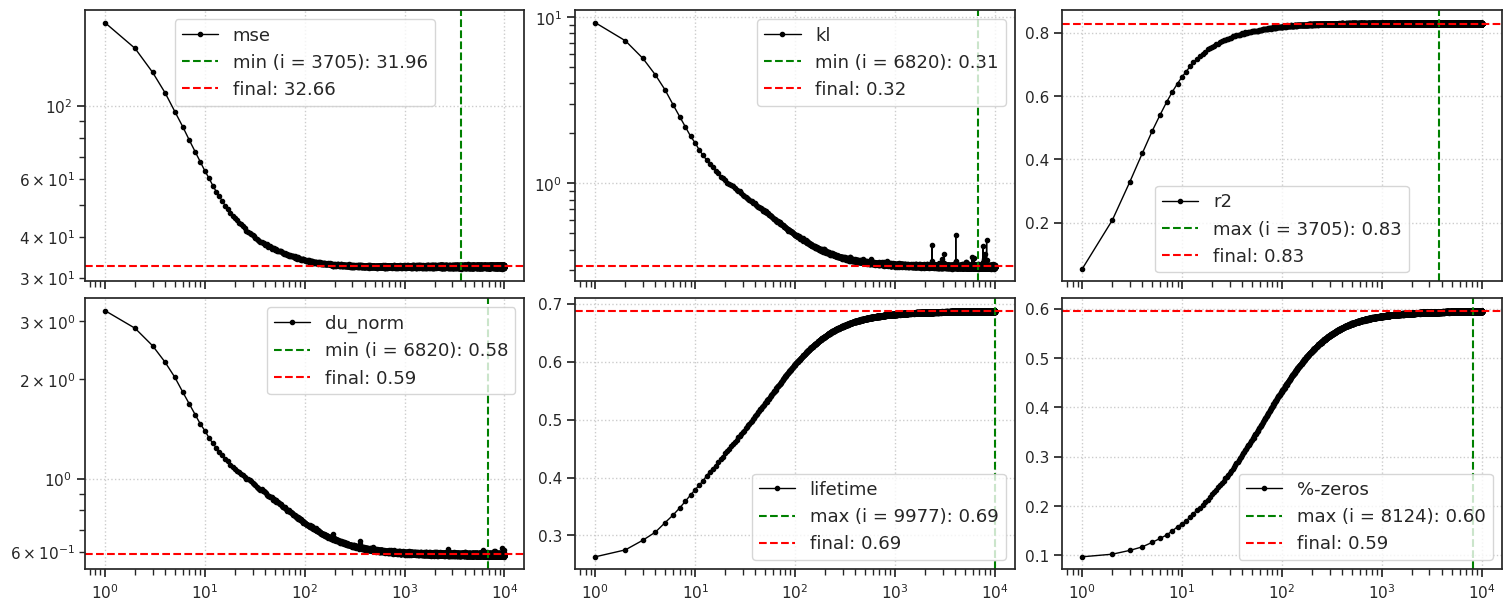

CPU times: user 1min 10s, sys: 31.6 s, total: 1min 42s
Wall time: 1min 42s


In [12]:
### Was: w/o Fisher

100%|███████████████████████████████████| 2/2 [01:12<00:00, 36.35s/it]


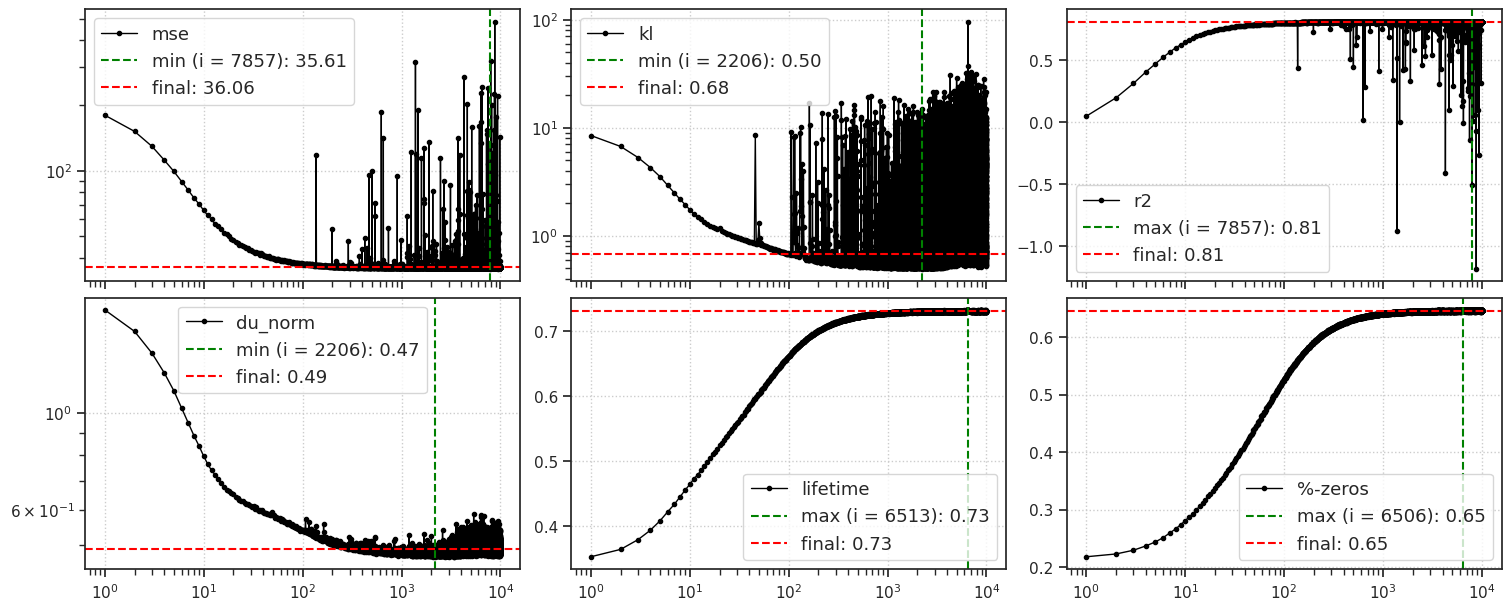

CPU times: user 56.4 s, sys: 56.2 s, total: 1min 52s
Wall time: 1min 52s


In [14]:
### Was: w/ Fisher